In [1]:
# fix file
import os

def fix_file(filepath):
    bad_filepath = '/'.join(filepath.split('/')[:-1]) + '/_' + filepath.split('/')[-1]
    if not os.path.exists(bad_filepath):
        os.rename(filepath, bad_filepath)
    elif not os.path.samefile(filepath, bad_filepath):
        os.remove(bad_filepath)
        os.rename(filepath, bad_filepath)
    print(bad_filepath)
    with open(filepath, 'w') as new_file:
        bad_file = open(bad_filepath, 'r')
        line = bad_file.readline()
        while line:
            if line.endswith('; \n') or line.endswith('; '):
                new_file.write(line[:-3] + '\n')
            else: new_file.write(line)
            line = bad_file.readline()

# file = './results/final_datasets/results_diff_2024-02-20T100948.txt'
# file = './results/final_datasets/results_no_diff_2024-02-19T105846.txt'

# file = './results/final_datasets/results_diffNN_2024-02-24T193319.txt'
# file = './results/final_datasets/results_diffNN_2024-02-25T160224.txt'
# for file in os.listdir("./results/final_datasets_rnn"):
#     if ".txt" in file: fix_file("./results/final_datasets_rnn/" + file)

models: FNN3_PCC
1L min_idx (np.float64(50.0), np.int64(75))
min_err: 1.9040000000000001 ; rel_err 1.517131474103586
2L min_idx (np.float64(37.5), np.int64(85))
min_err: 1.8472499999999998 ; rel_err 1.4719123505976095
3L min_idx (np.float64(100.0), np.int64(85))
min_err: 1.69675 ; rel_err 1.35199203187251
4L min_idx (np.float64(87.5), np.int64(50))
min_err: 1.644 ; rel_err 1.3099601593625498
models: FNN6_PCC
1L min_idx (np.float64(87.5), np.int64(70))
min_err: 1.6904 ; rel_err 1.3469322709163347
2L min_idx (np.float64(75.0), np.int64(75))
min_err: 1.8495 ; rel_err 1.4737051792828686
3L min_idx (np.float64(100.0), np.int64(65))
min_err: 1.623 ; rel_err 1.2932270916334663
4L min_idx (np.float64(87.5), np.int64(70))
min_err: 1.452 ; rel_err 1.156972111553785


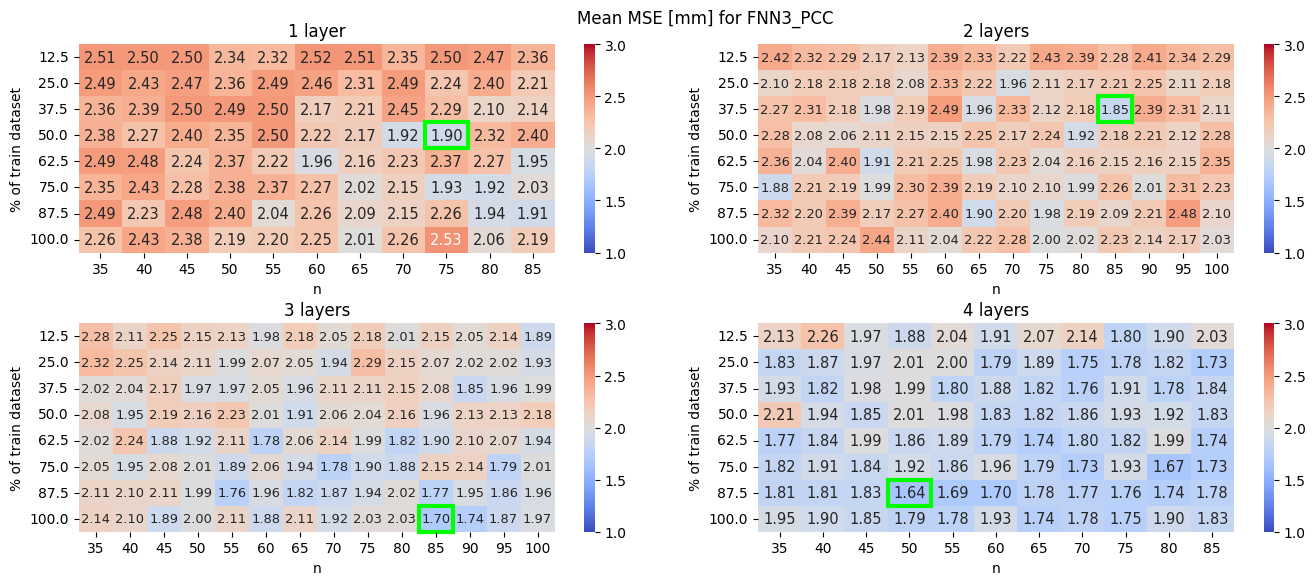

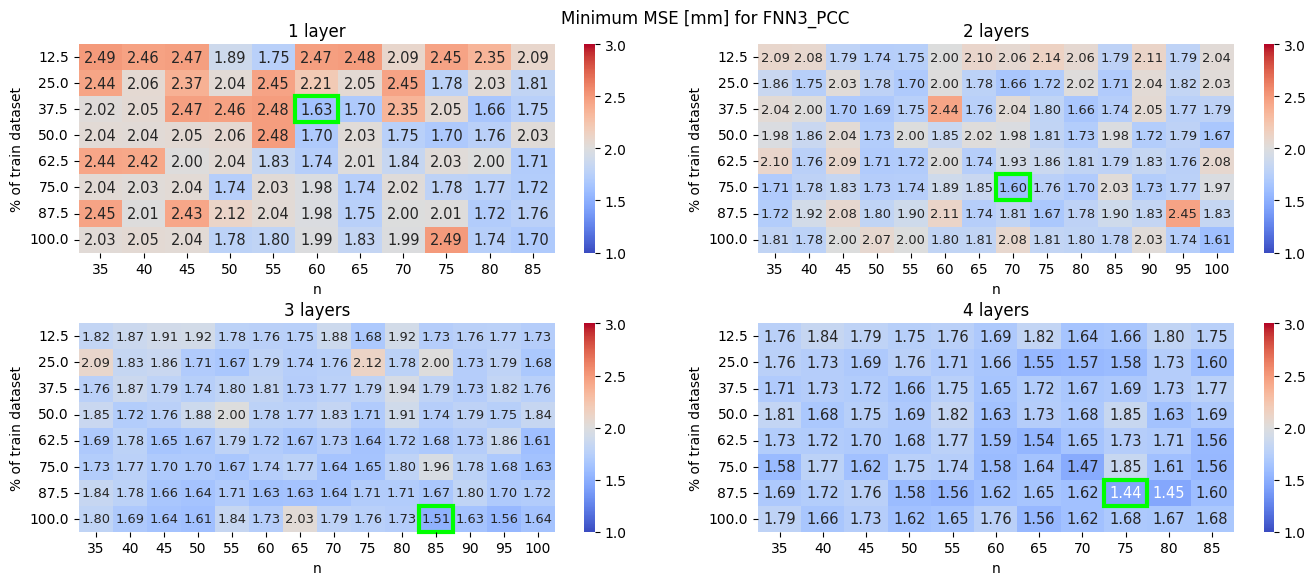

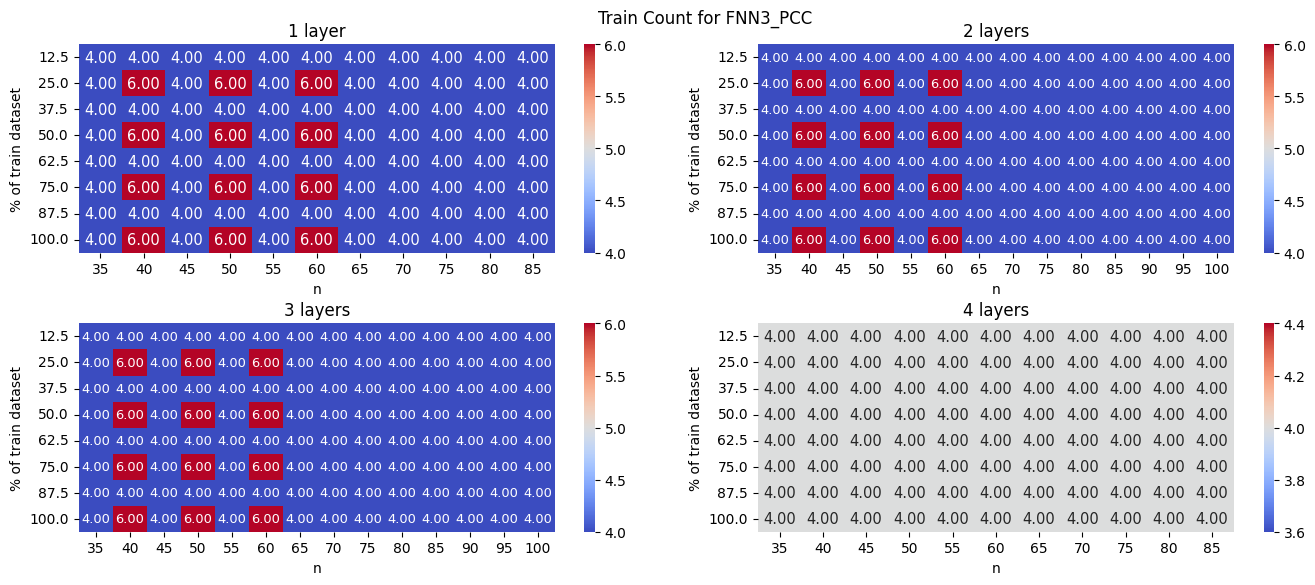

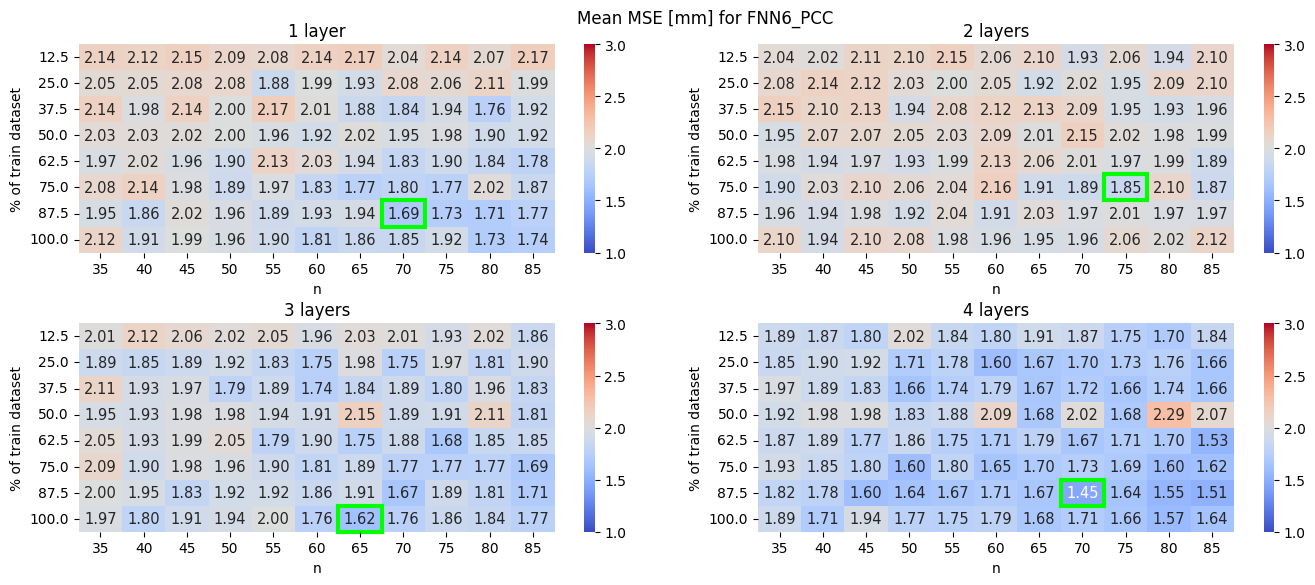

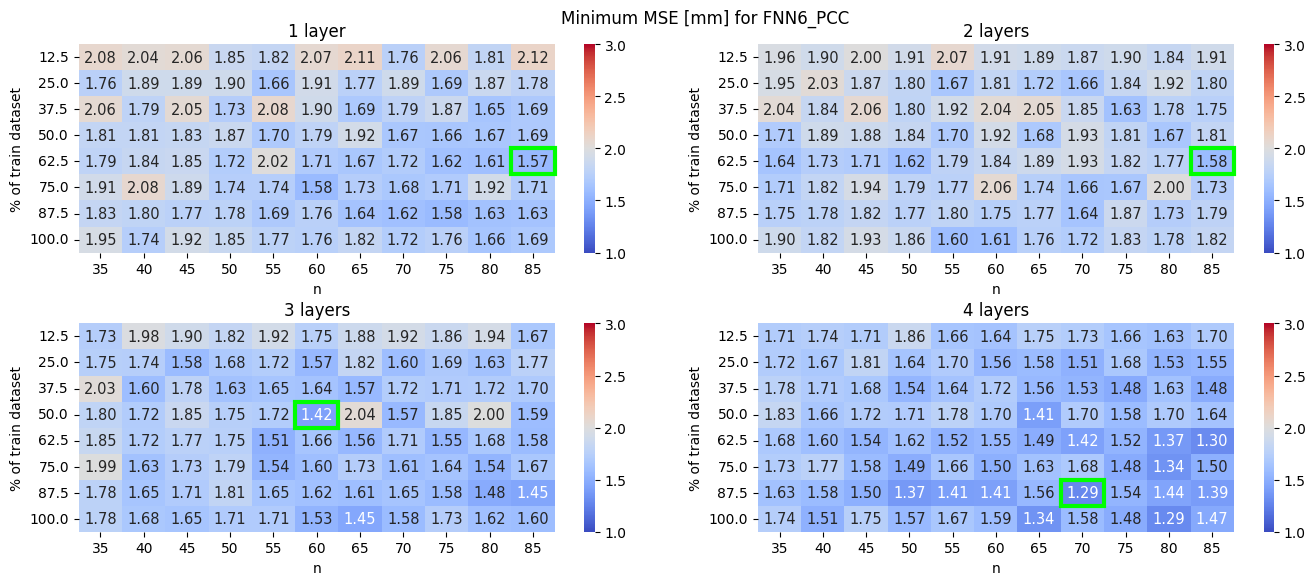

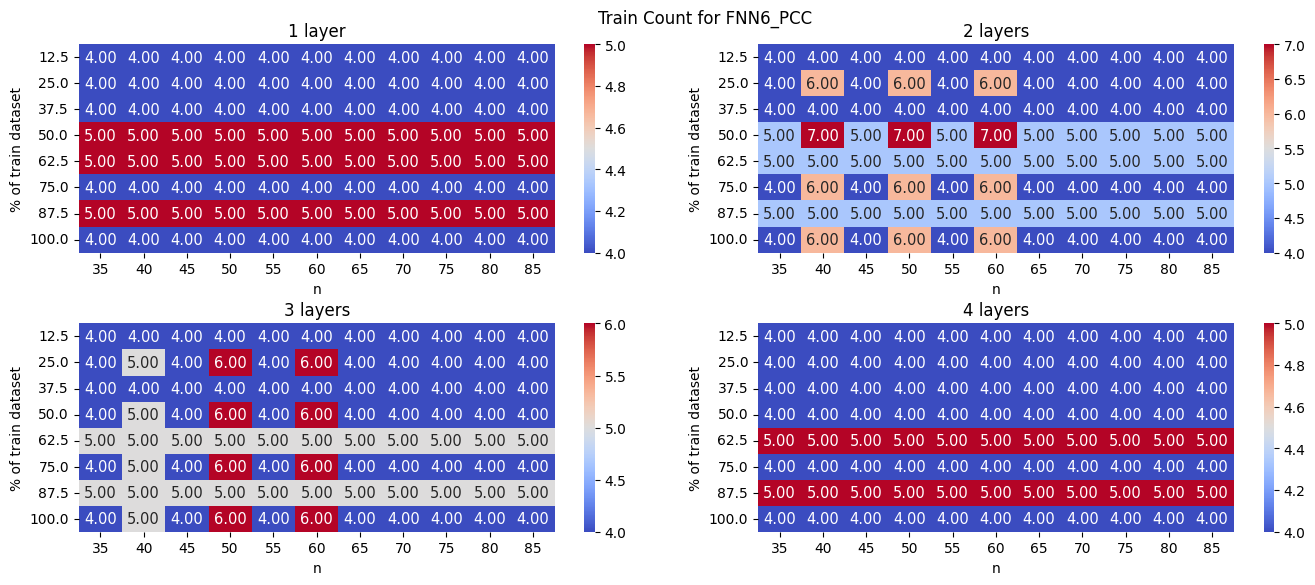

In [2]:
# tests mean and min, layers together, FNN

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = False
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
# result_files = ["./results/final_datasets2/" + file for file in os.listdir("./results/final_datasets2") if ".txt" in file and "_results" not in file] + \
models = ["rand", "diff_rand"]
models_title = ["FNN3_PCC", "FNN6_PCC"]

# models = ["rand"]
# models_title = ["FNN3_PCC"]
# models = ["diff_rand"]
# models_title = ["FNN6_PCC"]

folder = "./results/final_datasets_comp/"
result_files = [folder + file for file in os.listdir(folder) if ".txt" in file and "_results" not in file] 

# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

mean_vmaxs = [0, 3, 3, 3, 3]
min_vmaxs = [0, 3, 3, 3, 3]

for i, model in enumerate(models):
    print("models:", models_title[i])
    # result_files2 = []
    result_files2 = [file for file in result_files if folder in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n')
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] #+ \
        # [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files2[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
            df.insert(1, 'h', list(map(len, df['Architechture'])))
            df.insert(1, 'n', [arch[0] for arch in df['Architechture']])
            # print(df.head())
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
        dfs_concat = dfs_concat[dfs_concat['n'].astype(int) > 30]
    except Exception as e:
        print("failed concat:", e)
        continue

    # mean_fig, mean_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    mean_fig, mean_ax = plt.subplots(len(set(dfs_concat["h"]))//2, 2, figsize=(14, 6))
    mean_ax = mean_ax.flatten()
    mean_fig.tight_layout(pad=3)
    mean_fig.suptitle(f"Mean MSE [mm] for {models_title[i]}")
    # min_fig, min_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    min_fig, min_ax = plt.subplots(len(set(dfs_concat["h"]))//2, 2, figsize=(14, 6))
    min_fig.tight_layout(pad=3)
    min_ax = min_ax.flatten()
    min_fig.suptitle(f"Minimum MSE [mm] for {models_title[i]}")

    count_fig, count_ax = plt.subplots(len(set(dfs_concat["h"]))//2, 2, figsize=(14, 6))
    count_fig.tight_layout(pad=3)
    count_ax = count_ax.flatten()
    count_fig.suptitle(f"Train Count for {models_title[i]}")
    for j, h in enumerate(set(dfs_concat["h"])):
        if h > 1: s = 's'
        else: s = ''
        mean_ax[j].set_title(f"{h} layer{s}")
        min_ax[j].set_title(f"{h} layer{s}")
        count_ax[j].set_title(f"{h} layer{s}")
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=mean_ax[j], vmin=1, vmax=mean_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        print(f'{h}L min_idx {min_idx}')    
        print('min_err:', heatmap_data.loc[row_idx, col_idx], '; rel_err', heatmap_data.loc[row_idx, col_idx] / 1.255)
        mean_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        mean_ax[j].set_xlabel('n')
        mean_ax[j].set_ylabel(r'% of train dataset')

        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=min_ax[j], vmin=1, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        min_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))

        min_ax[j].set_xlabel('n')
        min_ax[j].set_ylabel(r'% of train dataset')

        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=count_ax[j], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})

        count_ax[j].set_xlabel('n')
        count_ax[j].set_ylabel(r'% of train dataset')

        if save_as_pgf:
            cbar = mean_ax[j].collections[0].colorbar
            for label in cbar.ax.get_yticklabels():
                label.set_fontname('sans-serif')
            cbar = min_ax[j].collections[0].colorbar
            for label in cbar.ax.get_yticklabels():
                label.set_fontname('sans-serif')
    # print(" ", file)

    if j+1 % 2 > 0:
        for ax in range(j+1, len(mean_ax)):
            mean_ax[ax].remove()
            min_ax[ax].remove()

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[i].lower()}_plots')
        mean_fig.suptitle(mean_fig._suptitle.get_text().replace(r'_', r'\_'))
        min_fig.suptitle(min_fig._suptitle.get_text().replace(r'_', r'\_'))
        # print(plots_folder)
        if not os.path.exists(plots_folder):
            os.mkdir(plots_folder)
        else:
            for file in os.listdir(plots_folder):
                os.remove(os.path.join(plots_folder, file))
        # if isinstance(ax, plt.Axes):
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_min_mae.pgf")
        # else:
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_all.pgf")
        mean_fig.savefig(plots_folder + f"/{models_title[i].lower()}_mean_mea.pgf")
        min_fig.savefig(plots_folder + f"/{models_title[i].lower()}_min_mea.pgf")
        print("plots saved in", plots_folder)



models: rand
./results/final_datasets_comp/results_diff_rand_2024-05-01T002559.txt
./results/final_datasets_comp/results_rand_2024-04-30T233236.txt
./results/final_datasets_comp/results_rand_2024-04-30T222115.txt
./results/final_datasets_comp/results_diff_rand_2024-04-30T181355.txt
./results/final_datasets_comp/results_diff_rand_2024-04-30T173101.txt
./results/final_datasets_comp/results_diff_rand_2024-05-03T110939.txt
./results/final_datasets_comp/results_diff_rand_2024-05-07T120103.txt
./results/final_datasets_comp/results_diff_rand_2024-06-04T111725.txt
./results/final_datasets_comp/results_diff_rand_2024-06-06T105400.txt
./results/final_datasets_comp/results_diff_rand_2024-06-06T002829.txt


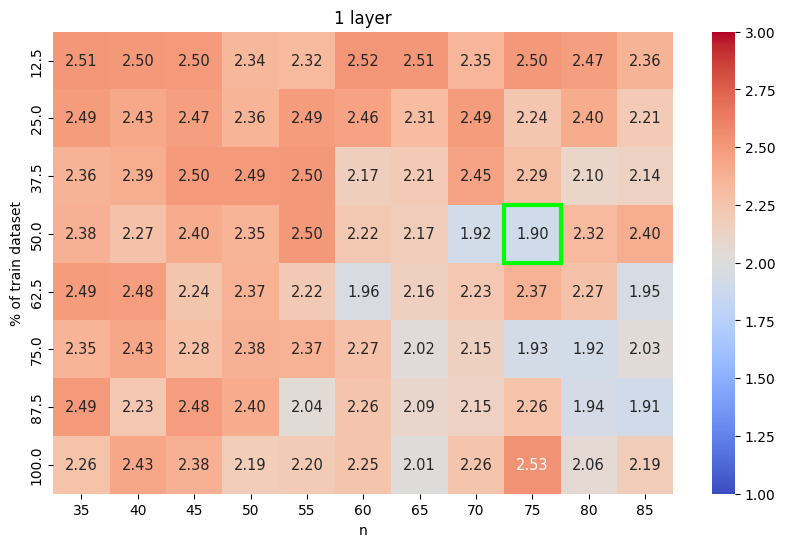

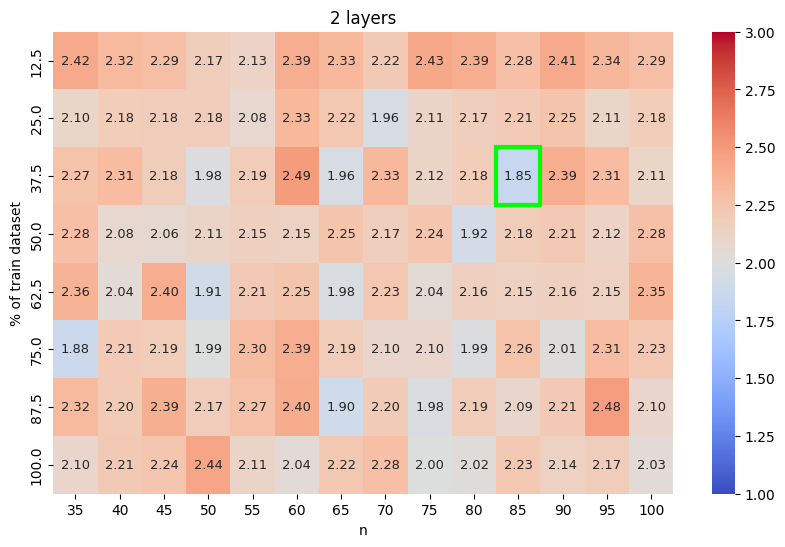

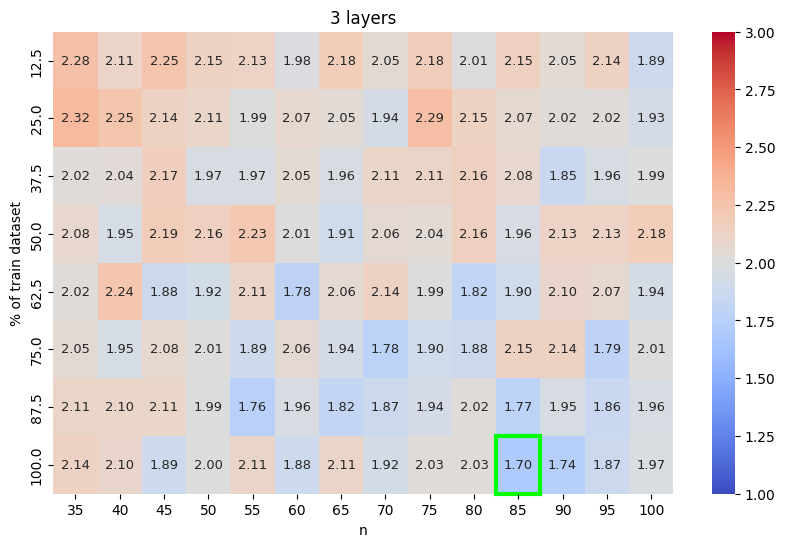

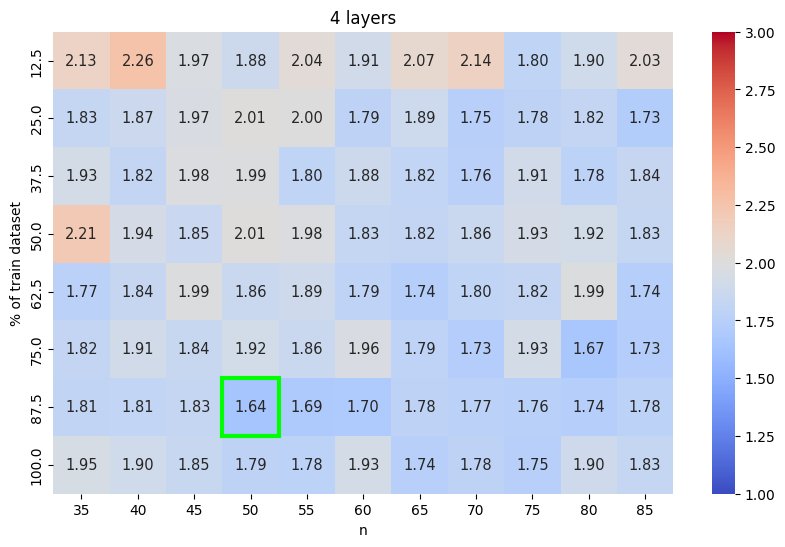

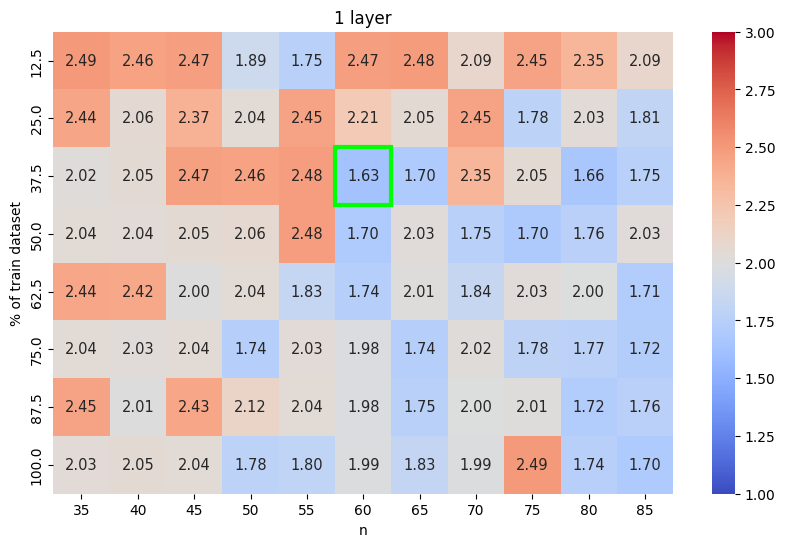

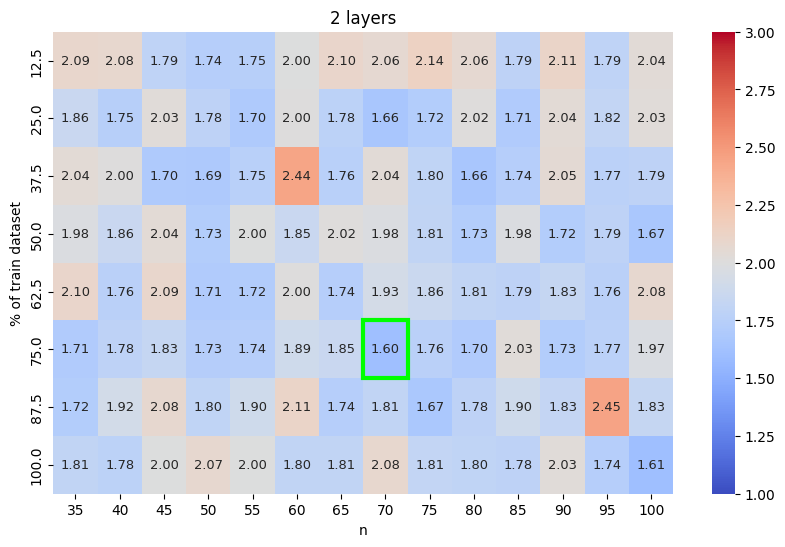

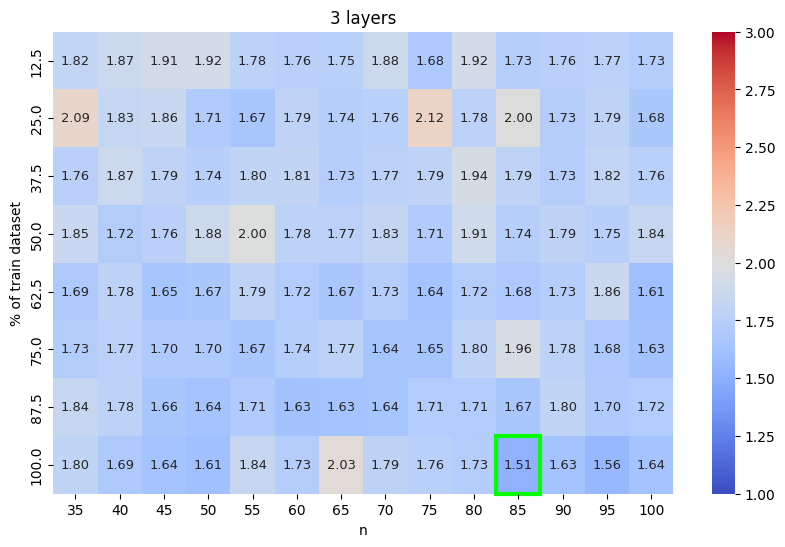

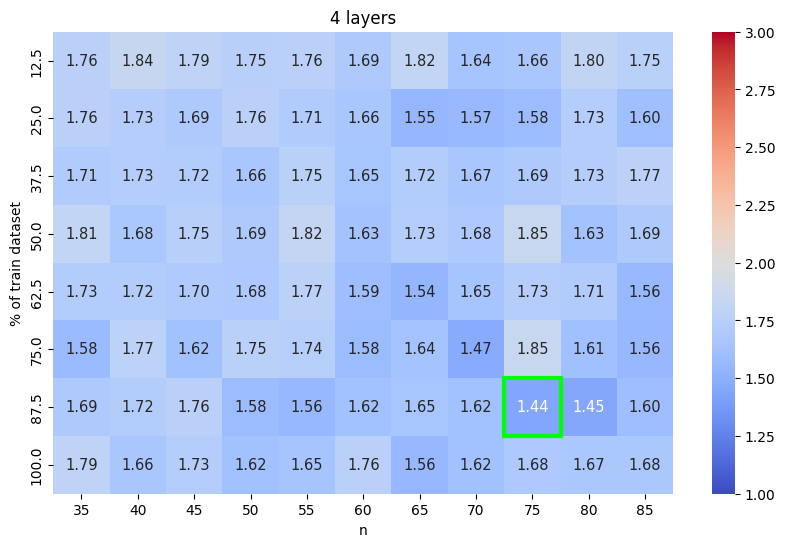

In [1]:
# tests mean and min, layers together, FNN (vert)

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# from math import ceil

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = False
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
# result_files = ["./results/final_datasets2/" + file for file in os.listdir("./results/final_datasets2") if ".txt" in file and "_results" not in file] + \
# models = ["rand", "diff_rand"]
# models_title = ["FNN3_PCC", "FNN6_PCC"]

models = ["rand"]
models_title = ["FNN3_PCC"]

# models = ["diff_rand"]
# models_title = ["FNN6_PCC"]

folder = "./results/final_datasets_comp/"
# folder = "./results/final_datasets_comp/"
result_files = [folder + file for file in os.listdir(folder) if ".txt" in file and "_results" not in file] 

# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

mean_vmaxs = [0, 3, 3, 3, 3]
min_vmaxs = [0, 3, 3, 3, 3]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if folder in file
           and ("results_" + model + "_2024") in file]
    
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] #+ \
        # [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
            df.insert(1, 'h', list(map(len, df['Architechture'])))
            df.insert(1, 'n', [arch[0] for arch in df['Architechture']])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
        dfs_concat = dfs_concat[dfs_concat['n'].astype(int) > 30]
    except Exception as e:
        print("failed concat:", e)
        continue

    # mean_fig, mean_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    # mean_fig, mean_ax = plt.subplots(len(set(dfs_concat["h"])), 1, figsize=(8, 16))
    mean_figs = [plt.figure(figsize=(10,6)) for _ in range(len(set(dfs_concat['h'])))]
    mean_ax = [fig.add_subplot() for fig in mean_figs]
    # mean_ax = mean_ax.flatten()
    # mean_fig.tight_layout(pad=3)
    # mean_fig.suptitle(f"Mean MSE [mm] for {models_title[i]}")
    # min_fig, min_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    # min_fig, min_ax = plt.subplots(len(set(dfs_concat["h"])), 1, figsize=(8, 16))
    # min_fig.tight_layout(pad=3)
    # min_ax = min_ax.flatten()
    min_figs = [plt.figure(figsize=(10,6)) for _ in range(len(set(dfs_concat['h'])))]
    min_ax = [fig.add_subplot() for fig in min_figs]
    # min_fig.suptitle(f"Minimum MSE [mm] for {models_title[i]}")

    # count_fig, count_ax = plt.subplots(len(set(dfs_concat["h"])), 1, figsize=(8, 16))
    # count_fig.tight_layout(pad=3)
    # count_ax = count_ax.flatten()
    # count_fig.suptitle(f"Train Count for {models_title[i]}")
    for j, h in enumerate(set(dfs_concat["h"])):
        if h > 1: s = 's'
        else: s = ''
        mean_ax[j].set_title(f"{h} layer{s}")
        min_ax[j].set_title(f"{h} layer{s}")
        # count_ax[j].set_title(f"{h} layer{s}")
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=mean_ax[j], vmin=1, vmax=mean_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        mean_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        mean_ax[j].set_xlabel('n')
        mean_ax[j].set_ylabel(r'% of train dataset')

        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=min_ax[j], vmin=1, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        min_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))

        min_ax[j].set_xlabel('n')
        min_ax[j].set_ylabel(r'% of train dataset')

        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=count_ax[j], vmin=1, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})

        # count_ax[j].set_xlabel('n')
        # count_ax[j].set_ylabel(r'% of train dataset')

        if save_as_pgf:
            cbar = mean_ax[j].collections[0].colorbar
            for label in cbar.ax.get_yticklabels():
                label.set_fontname('sans-serif')
            cbar = min_ax[j].collections[0].colorbar
            for label in cbar.ax.get_yticklabels():
                label.set_fontname('sans-serif')
    # print(" ", file)

    if j+1 % 2 > 0:
        for ax in range(j+1, len(mean_ax)):
            mean_ax[ax].remove()
            min_ax[ax].remove()

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[i].lower()}_plots-vert')
        # print(plots_folder)
        # mean_fig.suptitle(mean_fig._suptitle.get_text().replace(r'_', r'\_'))
        # min_fig.suptitle(min_fig._suptitle.get_text().replace(r'_', r'\_'))
        if not os.path.exists(plots_folder):
            os.mkdir(plots_folder)
        else:
            for file in os.listdir(plots_folder):
                os.remove(os.path.join(plots_folder, file))
        # if isinstance(ax, plt.Axes):
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_min_mae.pgf")
        # else:
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_all.pgf")
        for i in range(len(mean_figs())):
            mean_figs[i].savefig(plots_folder + f"/{models_title[i].lower()}_{i}L_mean_mea.pgf")
            min_figs[i].savefig(plots_folder + f"/{models_title[i].lower()}_{i}L_min_mea.pgf")

        # mean_fig.savefig(plots_folder + f"/{models_title[i].lower()}_mean_mea.pgf")
        # min_fig.savefig(plots_folder + f"/{models_title[i].lower()}_min_mea.pgf")
        print("plots saved in", plots_folder)



models: rand
1L min_idx (np.float64(87.5), np.int64(35))
min_err: 1.50575 ; rel_err 1.199800796812749
2L min_idx (np.float64(87.5), np.int64(30))
min_err: 1.47275 ; rel_err 1.1735059760956177
3L min_idx (np.float64(87.5), np.int64(30))
min_err: 1.53325 ; rel_err 1.2217131474103586
4L min_idx (np.float64(87.5), np.int64(30))
min_err: 1.54 ; rel_err 1.2270916334661357


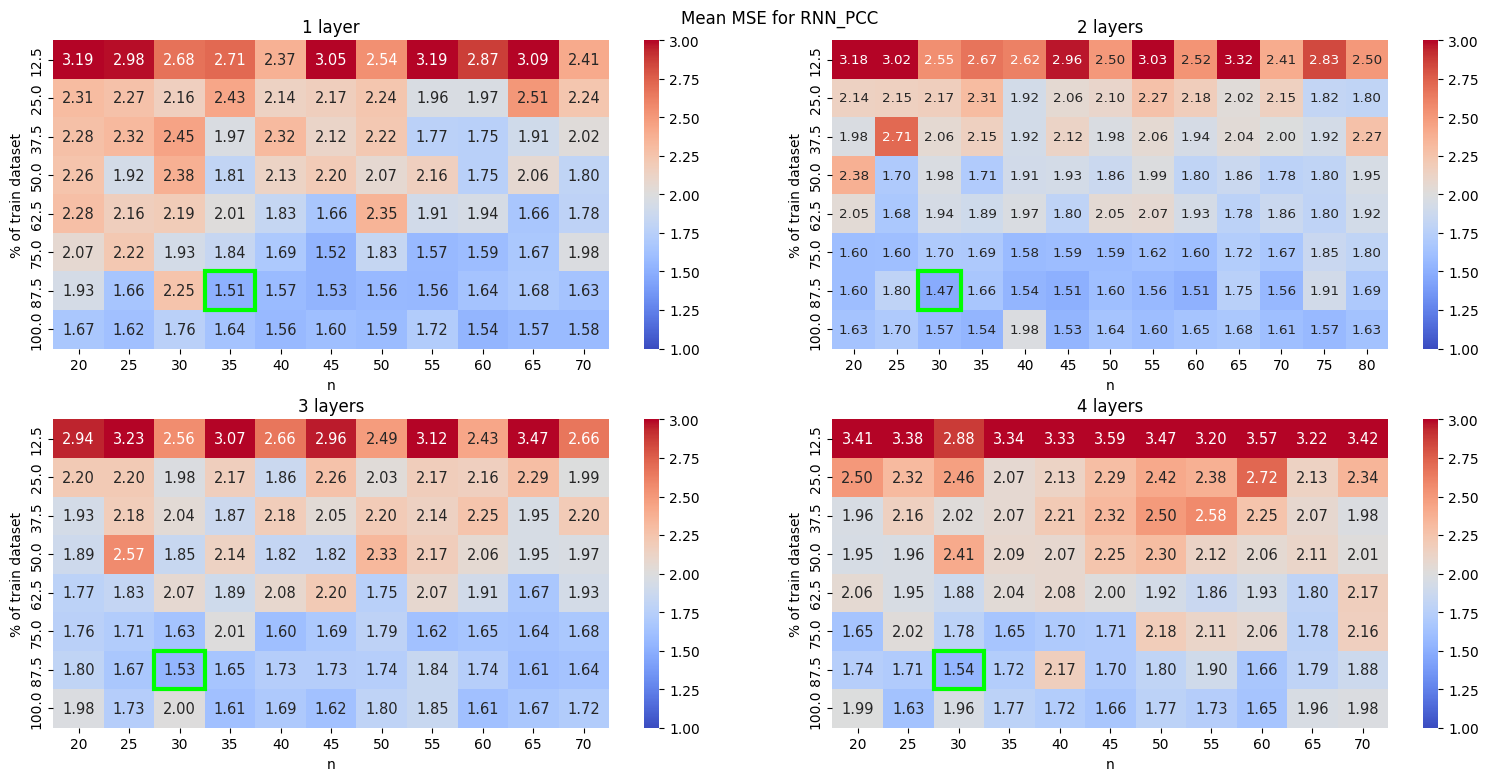

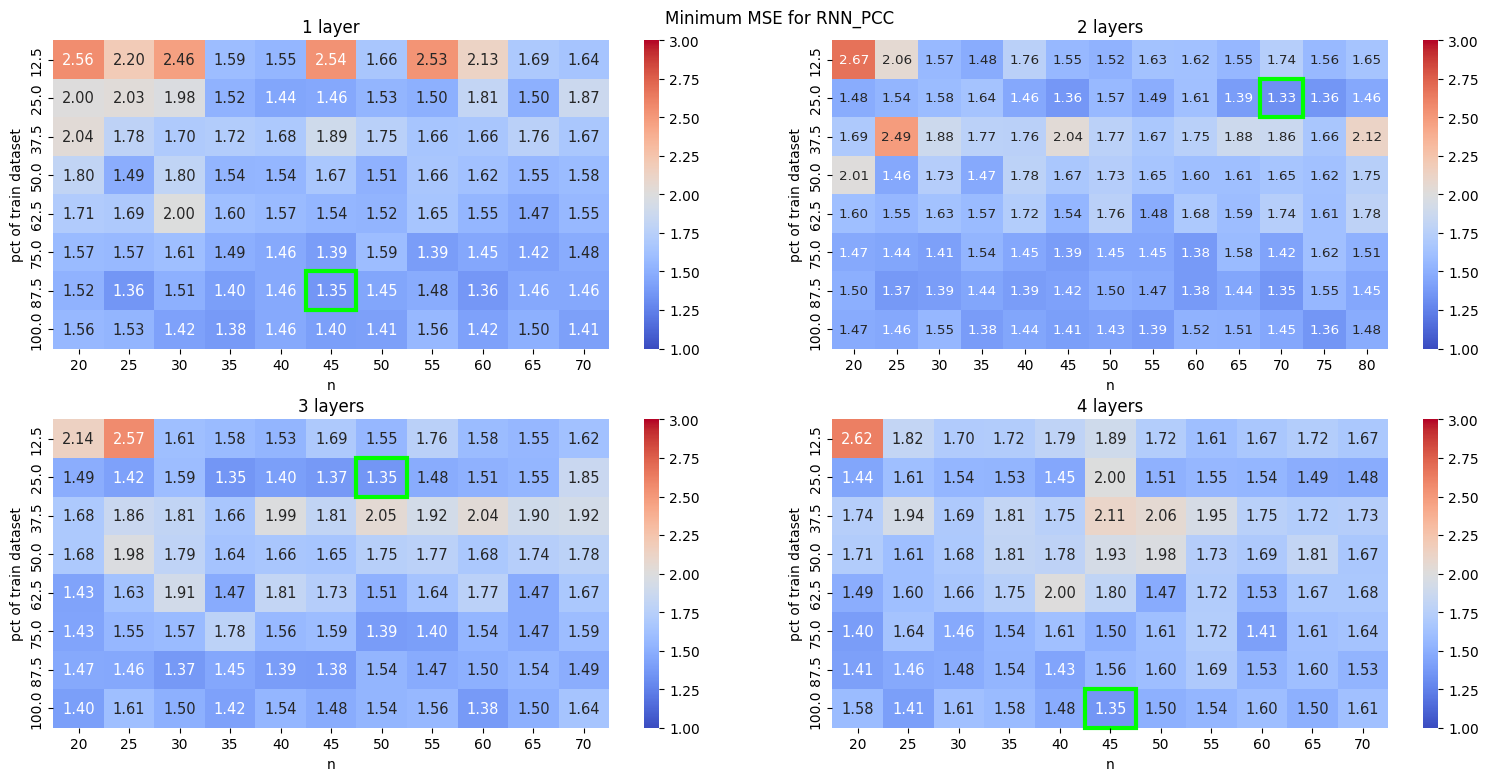

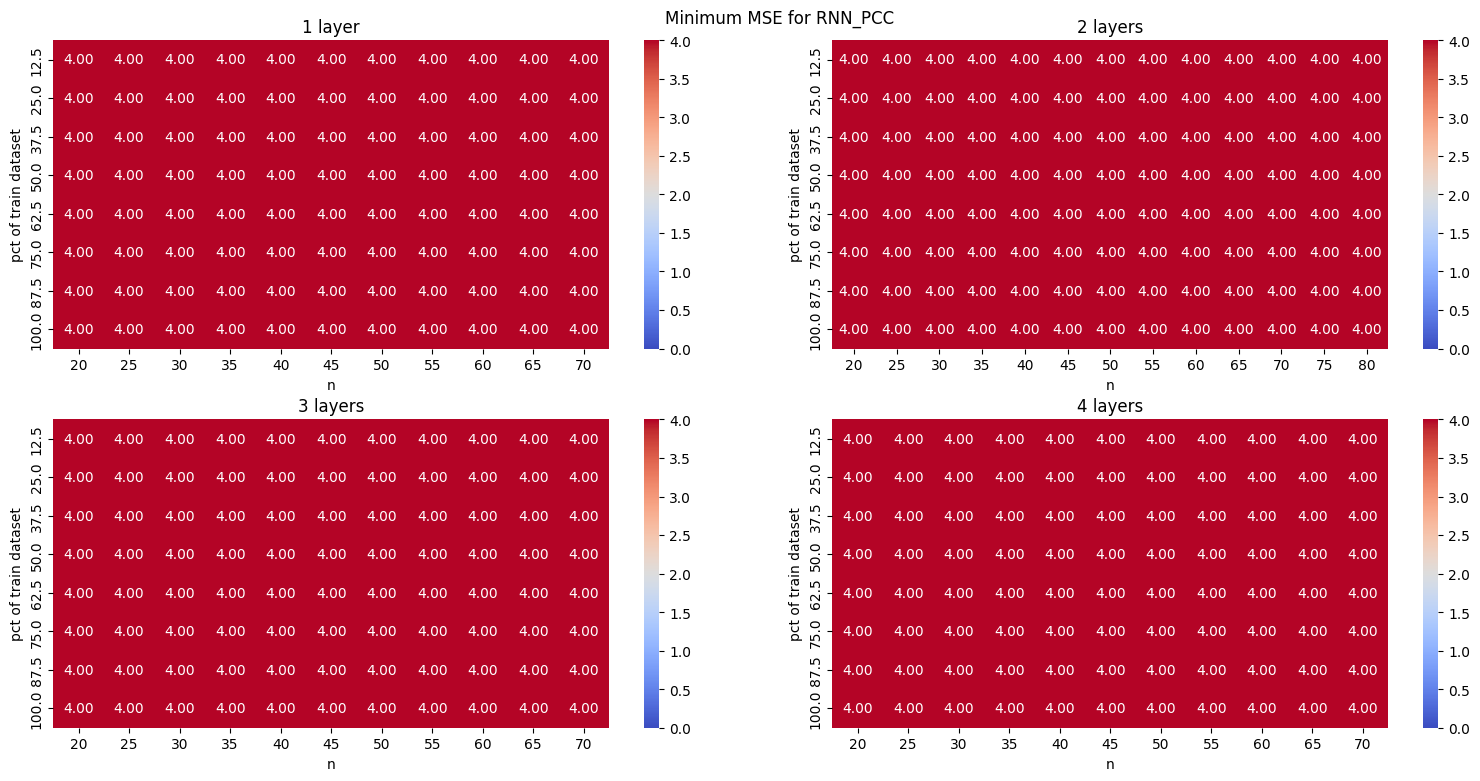

In [3]:
# tests mean and min, layers together, RNN
# %matplotlib inline
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from math import ceil

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = False
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })
# else:
#     # %matplotlib inline
#     import matplotlib
#     print(matplotlib.get_backend())
#     matplotlib.rcParams.update(matplotlib.rcParamsDefault)


models = ["rand"]
# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
models_title = ["RNN_PCC"]
folder = "./results/final_datasets_rnn_comp/"
result_files = [folder + file for file in os.listdir(folder) if ".txt" in file and "_results" not in file]

# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

mean_vmaxs = [0, 3, 3, 3, 3]
min_vmaxs = [0, 3, 3, 3, 3]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if folder in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [", ".join(arch.split(", ")[1:]).strip("[]") for arch in df['Architechture']]
            df.insert(1, 'n', [int(arch[1:].split(", ")[0]) for arch in df['Architechture']])
            df.insert(1, 'h', [row['Architechture'].count(str(row["n"])) for _, row in df[['Architechture', 'n']].iterrows()])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    # mean_fig, mean_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    # print(len(set(dfs_concat["h"])))
    mean_fig, mean_ax = plt.subplots(ceil(len(set(dfs_concat["h"]))/2), 2, figsize=(16, 8))
    mean_ax = mean_ax.flatten()
    mean_fig.tight_layout(pad=3)
    mean_fig.suptitle(f"Mean MSE for {models_title[i]}")
    # min_fig, min_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    min_fig, min_ax = plt.subplots(ceil(len(set(dfs_concat["h"]))/2), 2, figsize=(16, 8))
    min_fig.tight_layout(pad=3)
    min_ax = min_ax.flatten()
    min_fig.suptitle(f"Minimum MSE for {models_title[i]}")

    count_fig, count_ax = plt.subplots(ceil(len(set(dfs_concat["h"]))/2), 2, figsize=(16, 8))
    count_fig.tight_layout(pad=3)
    count_ax = count_ax.flatten()
    count_fig.suptitle(f"Minimum MSE for {models_title[i]}")
    for j, h in enumerate(set(dfs_concat["h"])):
        if h > 1: s = 's'
        else: s = ''
        mean_ax[j].set_title(f"{h} layer{s}")
        min_ax[j].set_title(f"{h} layer{s}")
        count_ax[j].set_title(f"{h} layer{s}")
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=mean_ax[j], vmin=1, vmax=mean_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        print(f'{h}L min_idx {min_idx}')    
        print('min_err:', heatmap_data.loc[row_idx, col_idx], '; rel_err', heatmap_data.loc[row_idx, col_idx] / 1.255)
        mean_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=min_ax[j], vmin=1, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        min_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min', fill_value=True)
        # heatmap_data.replace(True, np.nan, inplace=True)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0, vmax=vmaxs[h])
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc=np.argmin)
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.0f', ax=ax[2], vmin=0)
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=count_ax[j], vmin=0)
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[2].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # except Exception as e:
        #     print("failed plots:", e)
        #     continue

        mean_ax[j].set_xlabel('n')
        mean_ax[j].set_ylabel(r'% of train dataset')
    # print(" ", file)

    if j+1 % 2 > 0:
        for ax in range(j+1, len(mean_ax)):
            mean_ax[ax].remove()
            min_ax[ax].remove()

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[i].lower()}_plots')
        mean_fig.suptitle(mean_fig._suptitle.get_text().replace(r'_', r'\_'))
        min_fig.suptitle(min_fig._suptitle.get_text().replace(r'_', r'\_'))
        # print(plots_folder)
        if not os.path.exists(plots_folder):
            os.mkdir(plots_folder)
        else:
            for file in os.listdir(plots_folder):
                os.remove(os.path.join(plots_folder, file))
        # if isinstance(ax, plt.Axes):
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_min_mae.pgf")
        # else:
        #     fig.savefig(plots_folder + f"/{models_title[i].lower()}_{h}_all.pgf")
        mean_fig.savefig(plots_folder + f"/{models_title[i].lower()}_mean_mea.pgf")
        min_fig.savefig(plots_folder + f"/{models_title[i].lower()}_min_mea.pgf")


# plt.show()


In [12]:
# FIND BEST FNN Model

print("FIND BEST FNN Model")

import os
import sys
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

models = ["rand", "diff_rand"]
models_title = ["Random Points", "Random Points and Direction Vector"]
result_files = ["./results/final_datasets_comp/" + file for file in os.listdir("./results/final_datasets_comp") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if "./results/final_datasets_comp/" in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    best_model_error = 100
    best_model = ("", "", "")
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
            df['file'] = df_tup[0]
        except Exception as e:
            print(df_tup[0], e)
            # print(df_tup[1])
            # sys.exit()

        df.insert(1, 'h', list(map(len, df['Architechture'])))
        df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    #     min_model_idx = df["MAE [mm]"].idxmin()
    #     if (min_model_error := df.loc[min_model_idx, "MAE [mm]"]) < best_model_error:
    #         best_model_error = min_model_error
    #         best_model = (df_tup[0],
    #                       df.loc[min_model_idx, 'Architechture'],
    #                       df.loc[min_model_idx, 'pct of train dataset'],)
    #                     #   df.loc[min_model_idx, 'MAE [mm]'],
    #                     #   best_model_error)


    # print(best_model, best_model_error)
    print(dfs_concat.shape)
    print(dfs_concat.loc[dfs_concat['MAE [mm]'].idxmin(), 'file'])
    print(dfs_concat.sort_values("MAE [mm]")[:10].loc[:,["Architechture", "pct of train dataset", "MAE [mm]"]])
    print('\n'.join(dfs_concat.sort_values("MAE [mm]")[:5].loc[:,"file"].values))
           

FIND BEST FNN Model
models: rand
(1720, 14)
./results/final_datasets_comp/results_rand_2024-06-07T102829.txt
         Architechture  pct of train dataset  MAE [mm]
425   (75, 75, 75, 75)                  87.5     1.441
778   (80, 80, 80, 80)                  87.5     1.449
732   (70, 70, 70, 70)                  75.0     1.470
460       (85, 85, 85)                 100.0     1.515
335   (65, 65, 65, 65)                  62.5     1.544
203   (65, 65, 65, 65)                  25.0     1.547
1670      (95, 95, 95)                 100.0     1.560
383   (85, 85, 85, 85)                  75.0     1.561
467   (65, 65, 65, 65)                 100.0     1.561
773   (55, 55, 55, 55)                  87.5     1.561
./results/final_datasets_comp/results_rand_2024-06-07T102829.txt
./results/final_datasets_comp/results_rand_2024-06-08T124704.txt
./results/final_datasets_comp/results_rand_2024-06-08T124704.txt
./results/final_datasets_comp/results_rand_2024-06-07T102829.txt
./results/final_datasets_c

In [10]:
# FIND BEST RNN Model

print("FIND BEST RNN Model")

import os
import sys
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

# models = ["rand", "diff_rand", "diff_rand3N"]
models = ["rand"]
models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
result_files = ["./results/final_datasets_rnn_comp/" + file for file in os.listdir("./results/final_datasets_rnn_comp") if ".txt" in file and "_results" not in file]
# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    result_files2 = []
    # result_files2 = [file for file in result_files if "./results/final_datasets2/" in file
    #        and ("results_" + model + "_2024") in file]
    
    result_files3 = [file for file in result_files if "./results/final_datasets_rnn_comp/" in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    best_model_error = 100
    best_model = ("", "", "")
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] + \
        [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    # print(dfs[0][1]["pct of train dataset" > 25])
    # print(dfs[0][1]["pct of train dataset" > 25])
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [", ".join(arch.split(", ")[1:]).strip("[]") for arch in df['Architechture']]
            df.insert(1, 'n', [int(arch[1:].split(", ")[0]) for arch in df['Architechture']])
            df.insert(1, 'h', [row['Architechture'].count(str(row["n"])) for _, row in df[['Architechture', 'n']].iterrows()])
            df['file'] = df_tup[0]
        except Exception as e:
            print("DF processing failed:", e)
            print(df_tup[0])
            print(df_tup[1])
            # sys.exit()

    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    min_model_idx = dfs_concat["MAE [mm]"].idxmin()
    # print(df_tup[0])
    dfs_concat['arch'] = [(row['n'],)*row['h'] for _, row in dfs_concat.iterrows()]
    print(dfs_concat.loc[dfs_concat['MAE [mm]'].idxmin(), 'file'])
    print(dfs_concat.sort_values("MAE [mm]")[:10].loc[:,["pct of train dataset", 'arch', "MAE [mm]"]])
    print('\n'.join(dfs_concat.sort_values("MAE [mm]")[:10].loc[:,"file"].values))
    # if (min_model_error := df.loc[min_model_idx, "MAE [mm]"]) < best_model_error:
    #     best_model_error = min_model_error
    #     best_model = (
    #         # df_tup[0],
    #         dfs_concat.loc[min_model_idx, 'Architechture'],
    #         dfs_concat.loc[min_model_idx, 'pct of train dataset'],
    #         best_model_error)
        
            # print(best_model)
                        #   df.loc[min_model_idx, 'MAE [mm]'],


    # print(best_model)
    # print(df.shape)
    # print(df.head())



FIND BEST RNN Model
models: rand
./results/final_datasets_rnn_comp/results_rand_2024-06-11T204342.txt
      pct of train dataset              arch  MAE [mm]
603                   25.0          (70, 70)     1.326
335                   87.5          (70, 70)     1.352
243                  100.0  (45, 45, 45, 45)     1.352
11                    25.0      (50, 50, 50)     1.353
754                   25.0      (35, 35, 35)     1.354
1324                  87.5             (45,)     1.355
1322                  87.5             (25,)     1.356
666                   25.0          (75, 75)     1.358
694                  100.0          (75, 75)     1.358
750                   25.0          (45, 45)     1.361
./results/final_datasets_rnn_comp/results_rand_2024-06-11T204342.txt
./results/final_datasets_rnn_comp/results_rand_2024-06-10T152024.txt
./results/final_datasets_rnn_comp/results_rand_2024-06-10T101001.txt
./results/final_datasets_rnn_comp/results_rand_2024-05-04T222609.txt
./results/final_d

In [ ]:
#epochs
import matplotlib.pyplot as plt

s = ('s', '')
x_ticks = list(set(df['n']))
for h in set(df['h']):
    plt.figure(figsize=(5,3))
    plt.title(f'Epochs for {h} Layer{s[0] if h > 1 else s[1]}')
    plt.scatter(df[df['h'] == h]['n'], df[df['h'] == h]['Epochs'], label=f'{h} layers', c=df[df['h'] == h]['pct of train dataset'])
    ax = plt.gca()
    ax.set_xticks(x_ticks, list(map(str, x_ticks)))
    ax.set_xlabel('# of neurons')
    plt.colorbar()

NameError: name 'df' is not defined